# 17 · E2c: does the fitted program survive *conductance-based* synapses?

**Where E2 and E2b left off.** The fitted L1 is invariant across numerical substrates (Notebook 05). It also survives a change of *equations* to spiking neurons, with ~100 neurons per graded unit (Notebook 16). But both kept L1's **current-based synapses**: neuron j adds W_ij · s_j to neuron i whatever i's voltage.

**Real chemical synapses are conductances.** They pass current g_ij s_j (E_ij − v_i), so:
* their effect shrinks as v_i approaches the reversal potential E_ij;
* every open synapse lowers the neuron's input resistance (shunting).

This is the first change of equations that *biophysics* imposes, and it is **multiplicative** where L1 is additive. If the fitted program is software, it should survive being compiled onto conductance synapses.

**Compilation.**
* The model's dimensionless V is mapped to millivolts so that the neurons' resting potentials span a physiological range, −70 to −20 mV.
* Each synapse gets a reversal potential from its sign: excitatory 0 mV (cholinergic); inhibitory −80 mV (GABA_A or glutamate-gated chloride).
* Its conductance is set so that **at rest it injects exactly L1's current**: g_ij = W_ij / (E_ij − v_rest,i).

| compiler | matches L1… | what remains different |
|---|---|---|
| `naive` | at the resting point | the extra synaptic conductance changes each neuron's leak, hence its gain and time constant |
| `compensated` | at rest **and** in its linearisation around rest (the leak is lowered by the added conductance) | second-order effects only: shunting proper |

**The voltage scale is swept** (0.25× to 2× the physiological span). This brings neurons closer to the reversal potentials: a small scale is nearly current-based, a large one strongly shunting.

**What the synthetic checks showed while building this** (known L1s, two random 30-neuron wirings, at the physiological scale):
* `naive` failed clearly (gap/noise 2.2–2.3).
* `compensated` passed or nearly passed (0.015 and 0.115).
* At 2× scale the compensated network could become **unstable**: removing the added conductance from the leak gives a positive feedback that the shunting no longer limits. Unstable runs count as failures.
* **Compensation has a physical cost.** The leak must be lowered by a median 28 % of L1's leak. For 17 % of neurons it must be lowered by *more than all of it*, which a passive membrane cannot do. They would need an active inward conductance; *C. elegans* neurons do have persistent Ca²⁺ currents.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, glob, pickle, time, datetime, numpy as np, matplotlib.pyplot as plt, jax
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 15, 0), \
    f"Notebook 17 needs closurebench >= 0.15.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M_, substrates as SB, conductance as CD
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {"smoke":  dict(N_COLS=10, FOLDS_USED=1),
        "laptop": dict(N_COLS=None, FOLDS_USED=None),
        "full":   dict(N_COLS=None, FOLDS_USED=None)}[MODE]
globals().update(CONF)
SCALES = (0.25, 0.5, 1.0, 1.5, 2.0)
GAP_MAX, DFEVE_MAX = 0.1, 0.05
V_LO, V_HI, E_EXC, E_INH = -70.0, -20.0, 0.0, -80.0
TAG = "" if MODE == "full" else f"_{MODE}"

# ---- the fitted L1 models of Notebook 04 (as in Notebook 05); smoke falls back to a synthetic L1 if they are absent
E1_TAG = "_laptop" if MODE == "smoke" else TAG
try:
    e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
    e1_plan = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))
    assert e1_result["L_star"] == "L1", "conductance.py implements L1"
    c = e1_plan["config"]
    ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
    if c["n_neurons"] < ds.N:
        mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
        ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
    folds = M_.kfold_pairs(ds, c["k_folds"], c["fold_seed"])
    ck1 = os.path.join(RESULTS, f"e1_checkpoints{E1_TAG}")
    models = [pickle.load(open(os.path.join(ck1, f"fold{f}_L1_final.pkl"), "rb"))["params"] for f in range(c["k_folds"])]
    SOURCE = f"E1 fits ({E1_TAG.strip('_') or 'full'})"
except (FileNotFoundError, KeyError) as err:
    if MODE != "smoke":
        raise
    print("E1 fits not found (", err, ") -> smoke test on a synthetic L1")
    ds, p_true, _ = lad.make_synthetic(lad.random_wiring(N=30, S=10, seed=1, strains=("wt",)), true_level="L1", seed=1)
    st = lad.Structure.from_dataset(ds); cfg = lad.SimConfig(); folds = [None]; models = [p_true]; SOURCE = "synthetic L1"
rng = np.random.default_rng(0)
COLS = np.sort(rng.choice(ds.S, N_COLS, replace=False)) if N_COLS and N_COLS < ds.S else np.arange(ds.S)
FOLDS = list(range(len(models)))[:FOLDS_USED] if FOLDS_USED else list(range(len(models)))
print(f"source: {SOURCE} | {ds.N} neurons | {len(COLS)} stimuli | fold models {FOLDS}")
print(f"voltage scales {SCALES} (1 = resting potentials span {V_LO:g} to {V_HI:g} mV); E_exc {E_EXC:g} mV, E_inh {E_INH:g} mV")

source: E1 fits (laptop) | 120 neurons | 120 stimuli | fold models [0, 1, 2, 3, 4]
voltage scales (0.25, 0.5, 1.0, 1.5, 2.0) (1 = resting potentials span -70 to -20 mV); E_exc 0 mV, E_inh -80 mV


### Pre-registration (before §1)

Recorded in `results/E2c_preregistration*.json`. As in Notebooks 05 and 16, the reference is `ode` (the same fitted L1, RK4 dt = 0.02 s), and **pass** means gap/noise < 0.1 **and** |ΔFEVE| < 0.05 on held-out pairs, for every fold model.

* **CONDUCTANCE_TRANSFER:** `compensated` passes at the physiological scale (1.0). The fitted program is then invariant to conductance-based synapses, given that each neuron's leak is retuned for its synaptic load.
* **NAIVE_TRANSFER** (secondary): `naive` passes at scale 1.0. The program would then survive conductance synapses with no retuning at all.
* Descriptive:
  * the largest passing scale for each compiler (the *driving-force margin*);
  * the leak cost of compensation: the median fraction of leak removed, and the share of neurons needing more than all of it (an active conductance).

In [3]:
prereg = os.path.join(RESULTS, f"E2c_preregistration{TAG}.json")
plan = {"experiment": "E2c conductance-based synapses", "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "source": SOURCE, "config": {"N_COLS": int(len(COLS)), "folds": FOLDS, "scales": list(SCALES), "v_range_mV": [V_LO, V_HI], "E_exc": E_EXC, "E_inh": E_INH},
        "pass": f"gap/noise < {GAP_MAX} and |dFEVE| < {DFEVE_MAX} vs ode (RK4 dt 0.02), every fold model; unstable = fail",
        "CONDUCTANCE_TRANSFER": "compensated passes at scale 1.0",
        "NAIVE_TRANSFER": "naive passes at scale 1.0 (secondary)"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E2c_preregistration_laptop.json


## 1 · Compile and run every fold model at every voltage scale

All stimuli, all fold models (laptop and full). Each run takes seconds.

In [4]:
rows = []
for f in FOLDS:
    p = jax.tree_util.tree_map(jax.numpy.asarray, models[f])
    e = SB.effective_params("L1", p, st, COLS)
    R_ode = SB.simulate_numpy(e, ds.stim[COLS], cfg, "rk4", dt=0.02)
    Vr, Sr = CD.rest_state(e, cfg); vmap = CD.voltage_map(Vr, V_LO, V_HI)
    tm = None if folds[f] is None else folds[f]
    print(f"fold {f}: {vmap['kappa']:.1f} mV per model unit")
    for sc in SCALES:
        syn = CD.compile_synapses(e, Vr, Sr, vmap, scale=sc, E_exc=E_EXC, E_inh=E_INH)
        med_c, frac_c = CD.leak_feasibility(syn)
        for comp in (False, True):
            t0 = time.time()
            Rc = CD.simulate_conductance(e, ds.stim[COLS], cfg, syn, compensate=comp)
            stable = bool(np.all(np.isfinite(Rc)))
            r = dict(fold=f, scale=sc, compiler="compensated" if comp else "naive", stable=stable,
                     gap=SB.substrate_gap(Rc, R_ode, ds, COLS) if stable else float("inf"),
                     dfeve=(SB.feve_on(Rc, ds, COLS, tm) - SB.feve_on(R_ode, ds, COLS, tm)) if stable else float("-inf"),
                     leak_removed_median=med_c, frac_needing_active=frac_c, clipped=syn["frac_clipped"])
            rows.append(r)
            print(f"  scale {sc:4.2f} {r['compiler']:11s}: " + (f"gap/noise {r['gap']:8.3f} dFEVE {r['dfeve']:+.3f}" if stable else "UNSTABLE")
                  + (f" | leak removed (median) {med_c:.2f}, neurons needing an active conductance {frac_c:.0%}" if comp else "")
                  + f"  ({time.time() - t0:.0f} s)", flush=True)

fold 0: 6.7 mV per model unit
  scale 0.25 naive      : gap/noise    0.008 dFEVE -0.029  (4 s)
  scale 0.25 compensated: gap/noise    0.001 dFEVE -0.002 | leak removed (median) 0.04, neurons needing an active conductance 0%  (4 s)
  scale 0.50 naive      : gap/noise    0.019 dFEVE -0.056  (7 s)
  scale 0.50 compensated: gap/noise    0.001 dFEVE -0.003 | leak removed (median) 0.07, neurons needing an active conductance 0%  (7 s)
  scale 1.00 naive      : gap/noise    0.041 dFEVE -0.099  (6 s)
  scale 1.00 compensated: gap/noise    0.002 dFEVE -0.006 | leak removed (median) 0.15, neurons needing an active conductance 5%  (5 s)
  scale 1.50 naive      : gap/noise    0.058 dFEVE -0.129  (4 s)
  scale 1.50 compensated: gap/noise    0.005 dFEVE -0.015 | leak removed (median) 0.23, neurons needing an active conductance 8%  (5 s)
  scale 2.00 naive      : gap/noise    0.071 dFEVE -0.150  (5 s)
  scale 2.00 compensated: UNSTABLE | leak removed (median) 0.33, neurons needing an active conductanc

## 2 · Does the program survive conductance synapses?

 scale |  naive gap   dFEVE | compensated gap   dFEVE   (mean over folds; inf = unstable)
  0.25 |      0.008  -0.032 |           0.001  -0.003
  0.50 |      0.020  -0.063 |           0.001  -0.004
  1.00 |      0.043  -0.109 |           0.002  -0.005
  1.50 |      0.060  -0.140 |           0.006  -0.009
  2.00 |      0.073  -0.161 |             inf    -inf

leak cost at the physiological scale: median 15% of L1's leak removed; 5% of neurons would need an active (inward) conductance
largest passing scale (driving-force margin): {'naive': 0.25, 'compensated': 1.5}
Registered rules -> CONDUCTANCE_TRANSFER (compensated, scale 1): True | NAIVE_TRANSFER: False


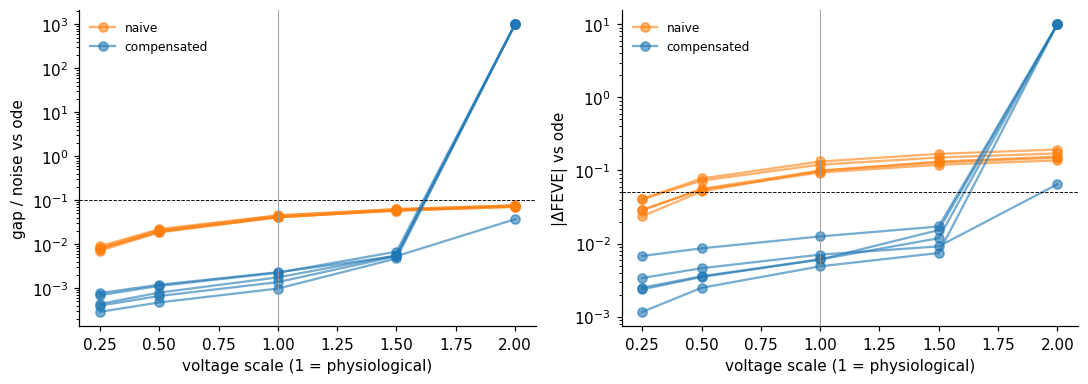

In [5]:
passes = lambda r: r["stable"] and r["gap"] < GAP_MAX and abs(r["dfeve"]) < DFEVE_MAX
def all_pass(comp, sc):
    rs = [r for r in rows if r["compiler"] == comp and r["scale"] == sc]
    return bool(rs) and all(passes(r) for r in rs)
CONDUCTANCE_TRANSFER = all_pass("compensated", 1.0)
NAIVE_TRANSFER = all_pass("naive", 1.0)
margin = {comp: max([sc for sc in SCALES if all_pass(comp, sc)], default=None) for comp in ("naive", "compensated")}
print(f"{'scale':>6s} | {'naive gap':>10s} {'dFEVE':>7s} | {'compensated gap':>15s} {'dFEVE':>7s}   (mean over folds; inf = unstable)")
for sc in SCALES:
    m = {comp: [r for r in rows if r["compiler"] == comp and r["scale"] == sc] for comp in ("naive", "compensated")}
    print(f"{sc:6.2f} | {np.mean([r['gap'] for r in m['naive']]):10.3f} {np.mean([r['dfeve'] for r in m['naive']]):+7.3f} | "
          f"{np.mean([r['gap'] for r in m['compensated']]):15.3f} {np.mean([r['dfeve'] for r in m['compensated']]):+7.3f}")
c1 = [r for r in rows if r["compiler"] == "compensated" and r["scale"] == 1.0]
print(f"\nleak cost at the physiological scale: median {np.mean([r['leak_removed_median'] for r in c1]):.0%} of L1's leak removed; "
      f"{np.mean([r['frac_needing_active'] for r in c1]):.0%} of neurons would need an active (inward) conductance")
print("largest passing scale (driving-force margin):", margin)
print("Registered rules -> CONDUCTANCE_TRANSFER (compensated, scale 1):", CONDUCTANCE_TRANSFER, "| NAIVE_TRANSFER:", NAIVE_TRANSFER)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for comp, c in (("naive", "tab:orange"), ("compensated", "tab:blue")):
    for f in FOLDS:
        rs = [r for r in rows if r["compiler"] == comp and r["fold"] == f]
        ax[0].plot([r["scale"] for r in rs], [min(r["gap"], 1e3) for r in rs], "o-", c=c, alpha=0.6, label=comp if f == FOLDS[0] else None)
        ax[1].plot([r["scale"] for r in rs], [min(abs(r["dfeve"]), 10) for r in rs], "o-", c=c, alpha=0.6, label=comp if f == FOLDS[0] else None)
ax[0].axhline(GAP_MAX, c="k", ls="--", lw=0.6); ax[1].axhline(DFEVE_MAX, c="k", ls="--", lw=0.6)
for a, lab in zip(ax, ("gap / noise vs ode", "|ΔFEVE| vs ode")):
    a.axvline(1.0, c="0.6", lw=0.6); a.set_yscale("log"); a.set_xlabel("voltage scale (1 = physiological)"); a.set_ylabel(lab); a.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

In [6]:
out = {"source": SOURCE, "conductance_transfer": CONDUCTANCE_TRANSFER, "naive_transfer": NAIVE_TRANSFER, "margin": margin, "rows": rows}
json.dump(out, open(os.path.join(RESULTS, f"E2c_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E2c_result{TAG}.json")

saved E2c_result_laptop.json


## 3 · Reading the result

| CONDUCTANCE_TRANSFER | NAIVE_TRANSFER | reading for C2 |
|---|---|---|
| yes | yes | The program is indifferent to how synapses deliver current at physiological voltages: software in the strongest sense tested so far. |
| yes | no | The program survives conductance synapses **only if each neuron's leak is retuned to its synaptic load**. The "software" needs a compiler that knows the hardware: the realization must be co-adapted, as homeostatic regulation of intrinsic conductances would do. If many neurons need *more* leak removed than they have, the compiler also needs active conductances. |
| no | no | Shunting at physiological driving forces changes the fitted program. What was fitted is specific to additive (current-based) interaction, so it is less separable from its biophysics than E2/E2b suggested. |

**Limits.**
* One voltage map: resting potentials spread linearly over −70 to −20 mV. Real neurons' resting potentials are not known for this fitted model.
* Single reversal potentials per sign; real *C. elegans* synapses include excitatory glutamate and inhibitory acetylcholine receptors, and their signs come from the atlas sign estimate.
* Graded neurons with no voltage-gated channels. A full biophysical realization (e.g. Jaxley with Ca²⁺ and K⁺ channels) would change the equations further.